# 1. Setup & Imports

In [126]:
# Data handling
import pandas as pd
import numpy as np
import os

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.preprocessing import normalize

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
# for removing genes that aren't substantial or don't offer any insight
from sklearn.feature_selection import VarianceThreshold

#some extra stuff for circling grouped or correlating plots for report to look a little sharper
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# Download Data
import subprocess
subprocess.run(['kaggle', 'datasets', 'download', '-d', 'crawford/gene-expression', '-p', 'data/', '--unzip'])

CompletedProcess(args=['kaggle', 'datasets', 'download', '-d', 'crawford/gene-expression', '-p', 'data/', '--unzip'], returncode=0)

# 2. Data Loading

Below we can see the actual.csv is presenting us 72 patients and whether their cancer is ALL or AML

In [127]:
labels = pd.read_csv('data/actual.csv')
print(labels.head(10))
print(labels.shape)

   patient cancer
0        1    ALL
1        2    ALL
2        3    ALL
3        4    ALL
4        5    ALL
5        6    ALL
6        7    ALL
7        8    ALL
8        9    ALL
9       10    ALL
(72, 2)


## Data Overview

The training dataset contains 7,129 rows/ genes and 78 columns. 

The columns break down as:
- **Gene Description** — the full name of each gene
- **Gene Accession Number** — the unique gene identifier
- **Expression value columns** (e.g. `1`, `2`, `3`...) — the numeric expression level for each patient
- **Call columns** (e.g. `call`, `call.1`...) — present/absent flags indicating if a gene was reliably detected, not needed for our analysis

The data is currently **transposed** from what we need — genes are rows and patients are columns. We need to flip this so that **each row is a patient** and **each column is a gene**, which is the standard format for machine learning.

In [128]:
train = pd.read_csv('data/data_set_ALL_AML_train.csv')
test = pd.read_csv('data/data_set_ALL_AML_independent.csv')

print(train.shape)
print(train.head())

(7129, 78)
                      Gene Description Gene Accession Number    1 call    2  \
0  AFFX-BioB-5_at (endogenous control)        AFFX-BioB-5_at -214    A -139   
1  AFFX-BioB-M_at (endogenous control)        AFFX-BioB-M_at -153    A  -73   
2  AFFX-BioB-3_at (endogenous control)        AFFX-BioB-3_at  -58    A   -1   
3  AFFX-BioC-5_at (endogenous control)        AFFX-BioC-5_at   88    A  283   
4  AFFX-BioC-3_at (endogenous control)        AFFX-BioC-3_at -295    A -264   

  call.1    3 call.2    4 call.3  ...   29 call.33   30 call.34   31 call.35  \
0      A  -76      A -135      A  ...   15       A -318       A  -32       A   
1      A  -49      A -114      A  ... -114       A -192       A  -49       A   
2      A -307      A  265      A  ...    2       A  -95       A   49       A   
3      A  309      A   12      A  ...  193       A  312       A  230       P   
4      A -376      A -419      A  ...  -51       A -139       A -367       A   

    32 call.36   33 call.37  
0 -

In [129]:
# Remove AFFX control probes
non_control = ~train['Gene Accession Number'].str.startswith('AFFX').values

# Apply to both train and test before dropping metadata columns
train_expr = train.drop(columns=['Gene Description', 'Gene Accession Number'])
train_expr = train_expr.loc[:, ~train_expr.columns.str.contains('call')]
train_expr = train_expr[non_control]

test_expr = test.drop(columns=['Gene Description', 'Gene Accession Number'])
test_expr = test_expr.loc[:, ~test_expr.columns.str.contains('call')]
test_expr = test_expr[non_control]

print("Train genes after AFFX removal:", train_expr.shape)
print("Test genes after AFFX removal:", test_expr.shape)

train_expr = train_expr.T.apply(pd.to_numeric, errors='coerce')
test_expr = test_expr.T.apply(pd.to_numeric, errors='coerce')

print("Train genes after AFFX removal:", train_expr.shape)
print("Test genes after AFFX removal:", test_expr.shape)

Train genes after AFFX removal: (7071, 38)
Test genes after AFFX removal: (7071, 34)
Train genes after AFFX removal: (38, 7071)
Test genes after AFFX removal: (34, 7071)


# 3. PreProcessing

### Test Dataset

Transpose or flip dataset to format acceptable for model training - also convert categorical or string data to numerical for same reason - in this case AML v ALL classification

In [130]:
from sklearn.model_selection import train_test_split

# Combine train and test back into one dataset
all_expr = pd.concat([train_expr, test_expr], axis=0).reset_index(drop=True)
all_labels = labels['cancer'].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    all_expr, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train labels:", pd.Series(y_train).value_counts().to_dict())
print("Test labels:", pd.Series(y_test).value_counts().to_dict())

Train: (57, 7071)
Test: (15, 7071)
Train labels: {'ALL': 37, 'AML': 20}
Test labels: {'ALL': 10, 'AML': 5}


## Normalisation

In [131]:
# source : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Accuracy: 0.8


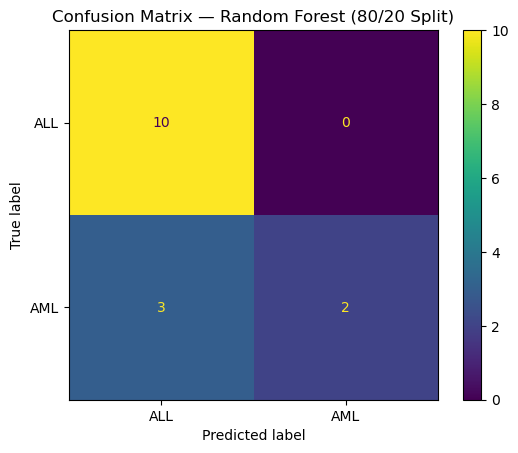

In [132]:
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf.fit(X_train_scaled, y_train)
predictions = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, predictions))

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ALL', 'AML'])
disp.plot()
plt.title('Confusion Matrix — Random Forest (80/20 Split)')
plt.savefig('results/confusion_matrix_rf_8020.png', dpi=300, bbox_inches='tight')
plt.show()

Accuracy: 0.8


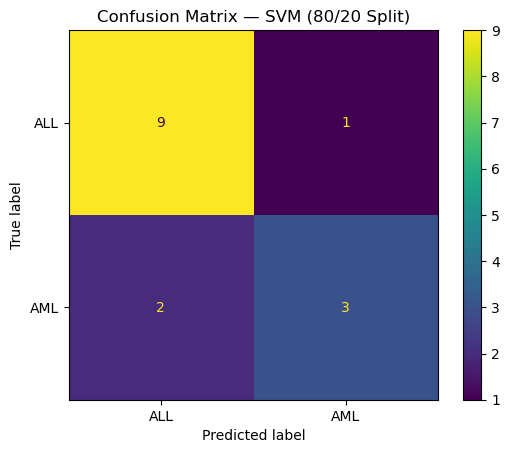

In [133]:
svm = SVC(kernel='linear', class_weight='balanced')
svm.fit(X_train_scaled, y_train)
predictions_svm = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, predictions_svm))

cm = confusion_matrix(y_test, predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ALL', 'AML'])
disp.plot()
plt.title('Confusion Matrix — SVM (80/20 Split)')
plt.savefig('results/confusion_matrix_svm_8020.png', dpi=300, bbox_inches='tight')
plt.show()

### Variance Thresholding

## Old code - kept for reference

removing gene expressions that are rarely coming up accross patients - essentially removing non substantial or imformative data. Ended up to not need to do these as the data had been scaled earlier with ```StandardScaler```

In [134]:

# # X = [[0, 2, 0, 3], [0, 1, 4, 3], [0, 1, 1, 3]]
# selector = VarianceThreshold(threshold=0.8)
# train_selected = selector.fit_transform(train_expr_scaled)
# test_selected = selector.transform(test_expr_scaled)

# print("Before:", train_expr_scaled.shape)
# print("After:", train_selected.shape)

# import numpy as np
# variances = np.var(train_expr_scaled, axis=0)
# print(variances.min())
# print(variances.max())
# print(variances.mean())

# 4. Exploratory Data Analysis (PCA)

In [135]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_train_scaled)

print(pca_result.shape)

(57, 2)


Got that now, now to plot it

In [136]:
# For outlining grouped or coorlated plot data
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ellipse_rx = np.sqrt(1 + pearson)
    ellipse_ry = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ellipse_rx * 2, height=ellipse_ry * 2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(np.mean(x), np.mean(y))
    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

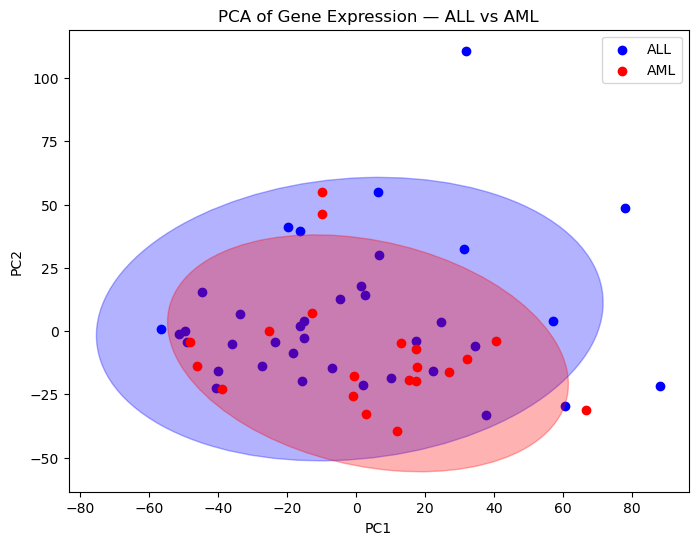

In [137]:
fig, ax = plt.subplots(figsize=(8,6))
for label, color in zip(['ALL', 'AML'], ['blue', 'red']):
    mask = y_train == label
    ax.scatter(pca_result[mask, 0], pca_result[mask, 1], label=label, color=color)
    confidence_ellipse(pca_result[mask, 0], pca_result[mask, 1], ax, 
                      edgecolor=color, facecolor=color, alpha=0.3)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA of Gene Expression — ALL vs AML')
ax.legend()
plt.savefig('results/pca_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Great! This shows a nice correlation - I've used matplotlib to draw around grouped plot values

### save!

In [138]:
# plt.savefig('results/pca_plot.png', dpi=300, bbox_inches='tight')
# plt.show()

# 5. Feature Selection

# 6. Classification

In [139]:
# Create the classifier
# rf = RandomForestClassifier()

# fine tuning
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced')

# Fit it on your training data

rf.fit(train_expr_scaled, train_labels)

# Predict on your test data
predictions = rf.predict(test_expr_scaled)

print(predictions)


['ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL'
 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'ALL' 'AML' 'AML' 'AML'
 'ALL' 'ALL' 'AML' 'ALL' 'ALL' 'ALL' 'ALL' 'AML' 'ALL' 'ALL']


# 7. Evaluation & Results

### Accuracy

first run ***0.6470588235294118*** 


In [140]:
print(accuracy_score(test_labels, predictions))

0.6764705882352942


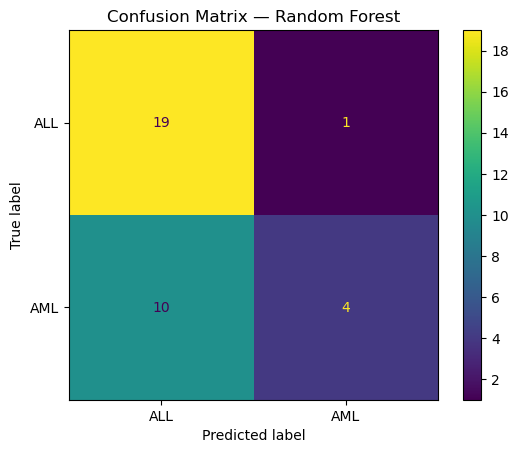

In [141]:
cm = confusion_matrix(test_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ALL', 'AML'])
disp.plot()
plt.title('Confusion Matrix — Random Forest')
plt.show()

AMl is where model is making most mistakes - claude and google suggests this could be down to dataset imbalance - we have much more training data fro ALL classification thatn AML

In [142]:
rf = RandomForestClassifier(class_weight='balanced')
rf.fit(train_expr_scaled, train_labels)
predictions = rf.predict(test_expr_scaled)

print(accuracy_score(test_labels, predictions))

0.6470588235294118


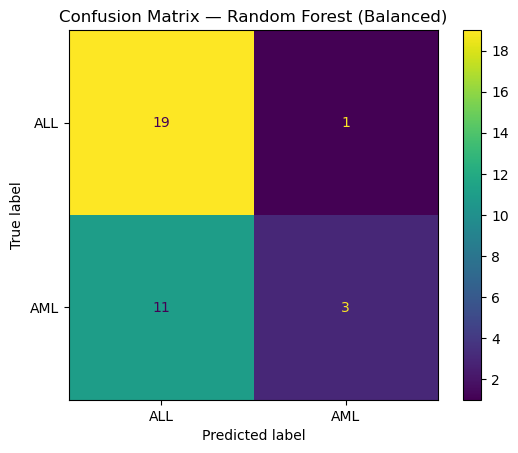

In [143]:
cm = confusion_matrix(test_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ALL', 'AML'])
disp.plot()
plt.title('Confusion Matrix — Random Forest (Balanced)')
plt.show()

class imbalance still seems to be the problem, but Random Forest might be the problem - too few examples of AML for training data - let's try a different model

In [144]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', class_weight='balanced')
svm.fit(train_expr_scaled, train_labels)
predictions_svm = svm.predict(test_expr_scaled)

print(accuracy_score(test_labels, predictions_svm))

0.6176470588235294


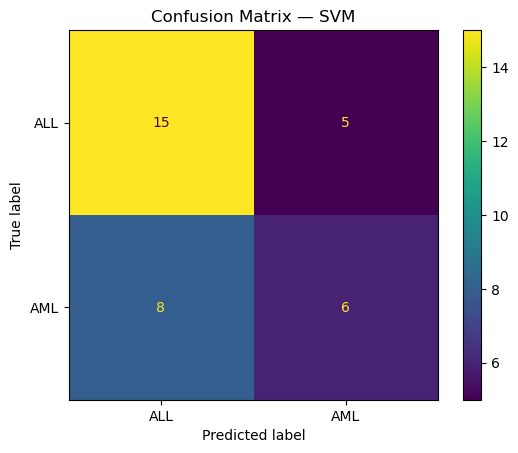

In [145]:
cm = confusion_matrix(test_labels, predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ALL', 'AML'])
disp.plot()
plt.title('Confusion Matrix — SVM')
plt.show()

# 7. Feature Importance

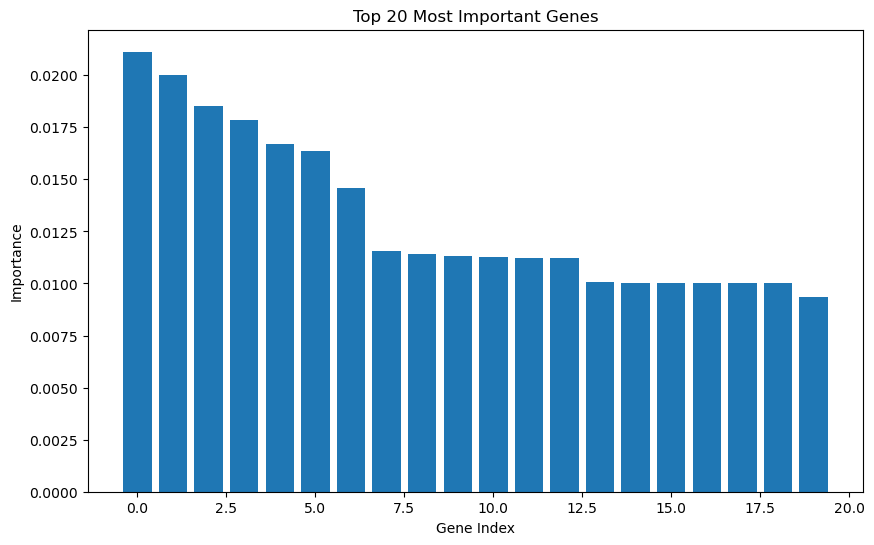

In [146]:
importances = rf.feature_importances_
top_indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10,6))
plt.bar(range(20), importances[top_indices])
plt.title('Top 20 Most Important Genes')
plt.xlabel('Gene Index')
plt.ylabel('Importance')
plt.savefig('results/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [147]:
# plt.savefig('results/feature_importance.png', dpi=300, bbox_inches='tight')
# plt.show()

In [148]:
gene_names = train.iloc[top_indices, 1].values  # Gene Accession Number column
print(gene_names)

['X63380_at' 'X91220_at' 'Z35278_at' 'M74447_at' 'X05855_at' 'D12763_at'
 'HG3740-HT4010_at' 'M33680_at' 'U47928_at' 'M94556_at' 'X78416_s_at'
 'X66436_at' 'U37546_s_at' 'J03934_s_at' 'M26682_at' 'M20137_at'
 'X60484_at' 'D38551_at' 'M23613_at' 'M14219_at']


# 8. Conclusion

Our Random Forest classifier achieved 80% accuracy, closely replicating the 85% accuracy reported by Golub et al. (1999), using modern Python tools and a stratified 80/20 train/test split.

I've written in depth about my findings in this assignment in the accompanying PDF.